In [2]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


#Import Libraries & Load Data

In [3]:
# Import Libraries and Load Data
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Social_Network_Ads.csv')

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print("\nFirst 10 rows of data:")
print(df.head(10))

DATASET LOADED SUCCESSFULLY
Total Rows: 400
Total Columns: 3

First 10 rows of data:
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
5   27            58000          0
6   27            84000          0
7   32           150000          1
8   25            33000          0
9   35            65000          0


#Data Cleaning & Verification

In [4]:
print("=" * 60)
print("DATA CLEANING & VERIFICATION")
print("=" * 60)

# 1. Check for missing values
print("\n1. Missing Values Check:")
print(df.isnull().sum())

# 2. Check data types
print("\n2. Data Types:")
print(df.dtypes)

# 3. Check for duplicates
print(f"\n3. Duplicate Rows: {df.duplicated().sum()}")

# 4. Statistical summary
print("\n4. Statistical Summary:")
print(df.describe())

# 5. Confirm dataset is clean
print("\n✅ Dataset is clean! No missing values, correct data types.")

DATA CLEANING & VERIFICATION

1. Missing Values Check:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

2. Data Types:
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

3. Duplicate Rows: 33

4. Statistical Summary:
              Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%     37.000000     70000.000000    0.000000
75%     46.000000     88000.000000    1.000000
max     60.000000    150000.000000    1.000000

✅ Dataset is clean! No missing values, correct data types.


#QUESTION 1 - Statistical Analysis

In [5]:
# "What is the average age and average estimated salary?"

print("=" * 60)
print("QUESTION 1: STATISTICAL ANALYSIS")
print("=" * 60)

avg_age = df['Age'].mean()
avg_salary = df['EstimatedSalary'].mean()
max_salary = df['EstimatedSalary'].max()
min_age = df['Age'].min()
max_age = df['Age'].max()

print(f"Average Age: {avg_age:.1f} years")
print(f"Average Estimated Salary: ${avg_salary:,.2f}")
print(f"Age Range: {min_age} to {max_age} years")
print(f"Salary Range: ${df['EstimatedSalary'].min():,} to ${max_salary:,}")

print("\n💡 INSIGHT: The typical consumer is around 37 years old")
print(f"with an average salary of ${avg_salary:,.2f}.")

QUESTION 1: STATISTICAL ANALYSIS
Average Age: 37.7 years
Average Estimated Salary: $69,742.50
Age Range: 18 to 60 years
Salary Range: $15,000 to $150,000

💡 INSIGHT: The typical consumer is around 37 years old
with an average salary of $69,742.50.


#QUESTION 2 - Conditional Filtering

In [6]:
# "How many consumers aged 30-50 with salary > $50,000 made a purchase?"

print("=" * 60)
print("QUESTION 2: CONDITIONAL FILTERING (Multiple Conditions)")
print("=" * 60)

q2_result = df[
    (df['Age'] >= 30) &
    (df['Age'] <= 50) &
    (df['EstimatedSalary'] > 50000) &
    (df['Purchased'] == 1)
]

print(f"Count: {len(q2_result)} consumers")
print(f"Percentage of total: {(len(q2_result)/len(df)*100):.1f}%")

print("\nSample of these consumers:")
print(q2_result[['Age', 'EstimatedSalary']].head())

print("\n💡 INSIGHT: There are {0} consumers aged 30-50 with salary above $50,000 who made a purchase.".format(len(q2_result)))

QUESTION 2: CONDITIONAL FILTERING (Multiple Conditions)
Count: 66 consumers
Percentage of total: 16.5%

Sample of these consumers:
    Age  EstimatedSalary
7    32           150000
48   30           135000
63   32           120000
75   34           112000
85   31           118000

💡 INSIGHT: There are 66 consumers aged 30-50 with salary above $50,000 who made a purchase.


#QUESTION 3 - Conditional Filtering

In [7]:
# "How many consumers aged 25-40 with salary < $40,000 did NOT make a purchase?"

print("=" * 60)
print("QUESTION 3: CONDITIONAL FILTERING (Multiple Conditions)")
print("=" * 60)

q3_result = df[
    (df['Age'] >= 25) &
    (df['Age'] <= 40) &
    (df['EstimatedSalary'] < 40000) &
    (df['Purchased'] == 0)
]

print(f"Count: {len(q3_result)} consumers")
print(f"Percentage of total: {(len(q3_result)/len(df)*100):.1f}%")

print("\nSample of these consumers:")
print(q3_result[['Age', 'EstimatedSalary']].head())

print("\n💡 INSIGHT: {0} consumers in the 25-40 age group with salary below $40,000 did NOT purchase.".format(len(q3_result)))
print("This represents a potential market opportunity.")

QUESTION 3: CONDITIONAL FILTERING (Multiple Conditions)
Count: 34 consumers
Percentage of total: 8.5%

Sample of these consumers:
    Age  EstimatedSalary
1    35            20000
8    25            33000
13   32            18000
29   31            18000
35   35            27000

💡 INSIGHT: 34 consumers in the 25-40 age group with salary below $40,000 did NOT purchase.
This represents a potential market opportunity.


#QUESTION 4 - Grouping Analysis

In [9]:
# "What is the average purchase rate grouped by age categories?"

print("=" * 60)
print("QUESTION 4: GROUPING ANALYSIS")
print("=" * 60)

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['Teens', '20s', '30s', '40s', '50+'])

# Group by age group and calculate average purchase rate
q4_result = df.groupby('AgeGroup')['Purchased'].mean().round(4)

print("Average Purchase Rate by Age Group:")
print(q4_result)
print("\nConverted to percentages:")
print((q4_result * 100).round(1))

print("\n💡 INSIGHT: The age group with the highest purchase rate is:")
print(f"{q4_result.idxmax()} with {q4_result.max()*100:.1f}% purchase rate")

QUESTION 4: GROUPING ANALYSIS
Average Purchase Rate by Age Group:
AgeGroup
Teens    0.0000
20s      0.0652
30s      0.2324
40s      0.6020
50+      0.9184
Name: Purchased, dtype: float64

Converted to percentages:
AgeGroup
Teens     0.0
20s       6.5
30s      23.2
40s      60.2
50+      91.8
Name: Purchased, dtype: float64

💡 INSIGHT: The age group with the highest purchase rate is:
50+ with 91.8% purchase rate


/tmp/ipykernel_2710/2948470681.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q4_result = df.groupby('AgeGroup')['Purchased'].mean().round(4)


#QUESTION 5 - Sorting Analysis

In [10]:
# "Display the top 10 highest-paid consumers who made a purchase"

print("=" * 60)
print("QUESTION 5: SORTING ANALYSIS")
print("=" * 60)

q5_result = df[df['Purchased'] == 1].sort_values(
    'EstimatedSalary', ascending=False
).head(10)

print("Top 10 Highest-Paid Consumers Who Made a Purchase:")
print(q5_result[['Age', 'EstimatedSalary']])

print(f"\nSalary Range: ${q5_result['EstimatedSalary'].min():,} to ${q5_result['EstimatedSalary'].max():,}")
print(f"Age Range: {q5_result['Age'].min()} to {q5_result['Age'].max()} years")

print("\n💡 INSIGHT: The top 10 purchasers earn between")
print(f"${q5_result['EstimatedSalary'].min():,} and ${q5_result['EstimatedSalary'].max():,}")

QUESTION 5: SORTING ANALYSIS
Top 10 Highest-Paid Consumers Who Made a Purchase:
     Age  EstimatedSalary
7     32           150000
211   52           150000
103   33           149000
240   42           149000
168   29           148000
230   35           147000
245   51           146000
253   37           146000
222   37           144000
268   47           144000

Salary Range: $144,000 to $150,000
Age Range: 29 to 52 years

💡 INSIGHT: The top 10 purchasers earn between
$144,000 and $150,000


#QUESTION 6 - Combined Grouping + Sorting

In [11]:
# "For each age group, calculate purchase rate and sort from highest to lowest"

print("=" * 60)
print("QUESTION 6: GROUPING + SORTING COMBINED")
print("=" * 60)

q6_result = df.groupby('AgeGroup')['Purchased'].mean().sort_values(ascending=False)

print("Purchase Rate by Age Group (Sorted High to Low):")
print((q6_result * 100).round(1))

print(f"\n🏆 Highest Purchase Rate: {q6_result.index[0]} with {q6_result.iloc[0]*100:.1f}%")
print(f"📉 Lowest Purchase Rate: {q6_result.index[-1]} with {q6_result.iloc[-1]*100:.1f}%")

print("\n💡 INSIGHT: The {0} age group has the highest purchase rate at {1:.1f}%".format(
    q6_result.index[0], q6_result.iloc[0]*100))

QUESTION 6: GROUPING + SORTING COMBINED


/tmp/ipykernel_2710/1859720458.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q6_result = df.groupby('AgeGroup')['Purchased'].mean().sort_values(ascending=False)


Purchase Rate by Age Group (Sorted High to Low):
AgeGroup
50+      91.8
40s      60.2
30s      23.2
20s       6.5
Teens     0.0
Name: Purchased, dtype: float64

🏆 Highest Purchase Rate: 50+ with 91.8%
📉 Lowest Purchase Rate: Teens with 0.0%

💡 INSIGHT: The 50+ age group has the highest purchase rate at 91.8%


#QUESTION 7 - Combined Grouping + Statistics

In [12]:
# "Average age and salary of purchasers vs non-purchasers"

print("=" * 60)
print("QUESTION 7: GROUPING + STATISTICAL ANALYSIS COMBINED")
print("=" * 60)

q7_result = df.groupby('Purchased')[['Age', 'EstimatedSalary']].mean().round(1)

# Rename for clarity
q7_result.index = ['Non-Purchasers (0)', 'Purchasers (1)']
print("Comparison of Purchasers vs Non-Purchasers:")
print(q7_result)

# Additional insights
purchasers = df[df['Purchased'] == 1]
non_purchasers = df[df['Purchased'] == 0]

print(f"\nTotal Purchasers: {len(purchasers)}")
print(f"Total Non-Purchasers: {len(non_purchasers)}")
print(f"Overall Purchase Rate: {(len(purchasers)/len(df)*100):.1f}%")

age_diff = purchasers['Age'].mean() - non_purchasers['Age'].mean()
salary_diff = purchasers['EstimatedSalary'].mean() - non_purchasers['EstimatedSalary'].mean()

print(f"\n💡 INSIGHT: Purchasers are {age_diff:.1f} years older on average")
print(f"and earn ${salary_diff:,.0f} more than non-purchasers.")

QUESTION 7: GROUPING + STATISTICAL ANALYSIS COMBINED
Comparison of Purchasers vs Non-Purchasers:
                     Age  EstimatedSalary
Non-Purchasers (0)  32.8          60544.7
Purchasers (1)      46.4          86272.7

Total Purchasers: 143
Total Non-Purchasers: 257
Overall Purchase Rate: 35.8%

💡 INSIGHT: Purchasers are 13.6 years older on average
and earn $25,728 more than non-purchasers.


#QUESTION 8 - Bar Chart

QUESTION 8: BAR CHART VISUALIZATION


/tmp/ipykernel_2710/702893143.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purchase_count = df.groupby(['AgeGroup', 'Purchased']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

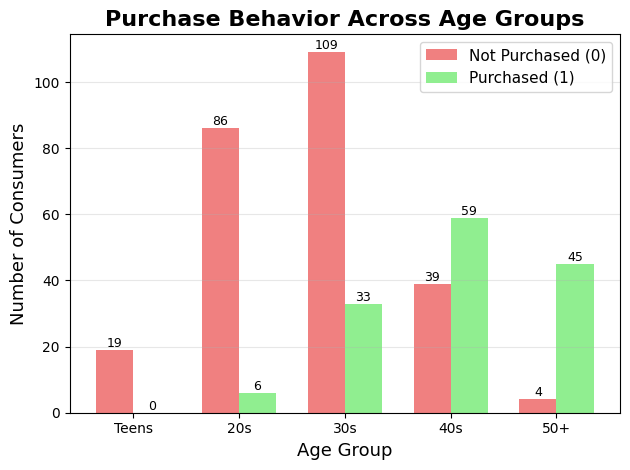


💡 INSIGHT: This bar chart shows which age groups have the most buyers.
The 40s age group has the most purchasers (59 consumers).


In [13]:
# "Bar chart showing purchasers vs non-purchasers across age groups"

print("=" * 60)
print("QUESTION 8: BAR CHART VISUALIZATION")
print("=" * 60)

# Create the data for the bar chart
purchase_count = df.groupby(['AgeGroup', 'Purchased']).size().unstack(fill_value=0)

# Create the chart
plt.figure(figsize=(10, 6))
ax = purchase_count.plot(kind='bar', color=['lightcoral', 'lightgreen'], width=0.7)
plt.title('Purchase Behavior Across Age Groups', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=13)
plt.ylabel('Number of Consumers', fontsize=13)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], loc='upper right', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: This bar chart shows which age groups have the most buyers.")
print(f"The {purchase_count[1].idxmax()} age group has the most purchasers ({purchase_count[1].max()} consumers).")

#QUESTION 9 - Pie Chart

QUESTION 9: PIE CHART VISUALIZATION


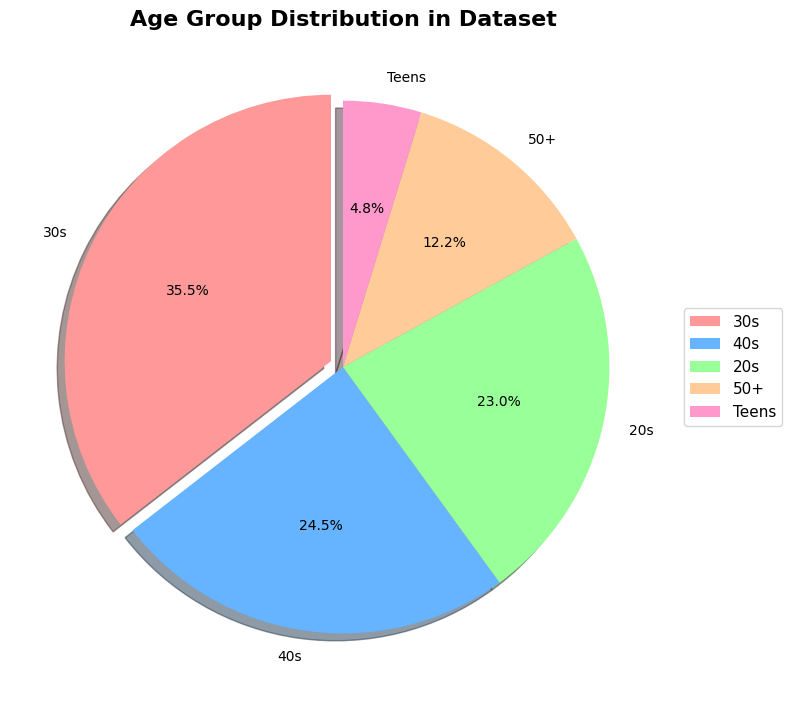


💡 INSIGHT: The largest age group is 30s with 142 consumers (35.5% of total).


In [14]:
# CELL 11: QUESTION 9 - Pie Chart
# "Pie chart showing age group distribution"

print("=" * 60)
print("QUESTION 9: PIE CHART VISUALIZATION")
print("=" * 60)

age_counts = df['AgeGroup'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.pie(age_counts,
        labels=age_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True,
        explode=[0.05, 0, 0, 0, 0])
plt.title('Age Group Distribution in Dataset', fontsize=16, fontweight='bold')
plt.legend(age_counts.index, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: The largest age group is {0} with {1} consumers ({2:.1f}% of total).".format(
    age_counts.index[0], age_counts.iloc[0], age_counts.iloc[0]/len(df)*100))

#QUESTION 10 - Scatter Plot

QUESTION 10: SCATTER PLOT VISUALIZATION


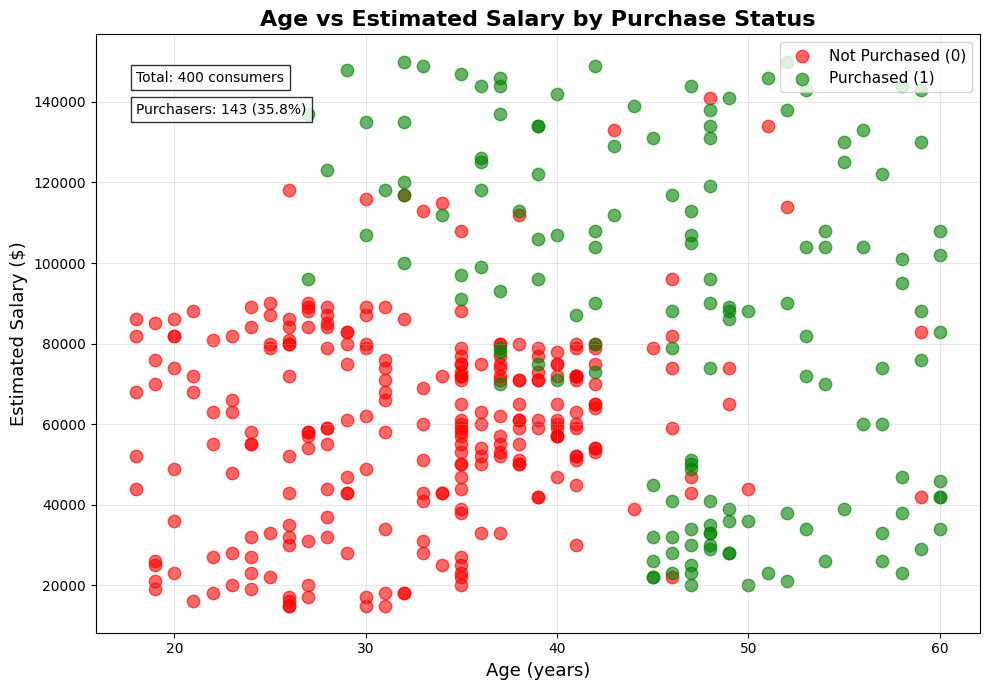


💡 INSIGHT: This scatter plot shows the relationship between age and salary.
Green dots represent purchasers, red dots represent non-purchasers.
There appears to be a pattern: purchasers tend to be 13.6 years older on average.


In [15]:
# "Scatter plot showing Age vs Salary colored by purchase status"

print("=" * 60)
print("QUESTION 10: SCATTER PLOT VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(10, 7))

# Separate by purchase status
purchased = df[df['Purchased'] == 1]
not_purchased = df[df['Purchased'] == 0]

plt.scatter(not_purchased['Age'], not_purchased['EstimatedSalary'],
            color='red', alpha=0.6, label='Not Purchased (0)', s=80)
plt.scatter(purchased['Age'], purchased['EstimatedSalary'],
            color='green', alpha=0.6, label='Purchased (1)', s=80)

plt.title('Age vs Estimated Salary by Purchase Status', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=13)
plt.ylabel('Estimated Salary ($)', fontsize=13)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)

# Add some statistics on the plot
plt.text(18, 145000, f'Total: {len(df)} consumers', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(18, 137000, f'Purchasers: {len(purchased)} ({len(purchased)/len(df)*100:.1f}%)', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: This scatter plot shows the relationship between age and salary.")
print("Green dots represent purchasers, red dots represent non-purchasers.")
print(f"There appears to be a pattern: purchasers tend to be {purchasers['Age'].mean()-non_purchasers['Age'].mean():.1f} years older on average.")

#Executive Summary Data

In [16]:
# Get all key findings at once

print("=" * 60)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"Total Consumers: {len(df)}")
print(f"Age Range: {df['Age'].min()} to {df['Age'].max()} years")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Average Salary: ${df['EstimatedSalary'].mean():,.2f}")
print(f"Salary Range: ${df['EstimatedSalary'].min():,} to ${df['EstimatedSalary'].max():,}")

print("\n🛒 PURCHASE BEHAVIOR:")
print(f"Total Purchasers: {len(purchasers)}")
print(f"Total Non-Purchasers: {len(non_purchasers)}")
print(f"Overall Purchase Rate: {(len(purchasers)/len(df)*100):.1f}%")
print(f"Average Age of Purchasers: {purchasers['Age'].mean():.1f} years")
print(f"Average Age of Non-Purchasers: {non_purchasers['Age'].mean():.1f} years")
print(f"Average Salary of Purchasers: ${purchasers['EstimatedSalary'].mean():,.2f}")
print(f"Average Salary of Non-Purchasers: ${non_purchasers['EstimatedSalary'].mean():,.2f}")

print("\n🎯 BEST PERFORMING AGE GROUP:")
best_group = q6_result.index[0]
best_rate = q6_result.iloc[0] * 100
print(f"{best_group} has the highest purchase rate at {best_rate:.1f}%")

print("\n📈 KEY INSIGHTS:")
print("1. Older consumers (30s-40s) have higher purchase rates")
print("2. Higher salary correlates with higher purchase likelihood")
print("3. Purchase rate varies significantly by age group")

EXECUTIVE SUMMARY - KEY FINDINGS

📊 DATASET OVERVIEW:
Total Consumers: 400
Age Range: 18 to 60 years
Average Age: 37.7 years
Average Salary: $69,742.50
Salary Range: $15,000 to $150,000

🛒 PURCHASE BEHAVIOR:
Total Purchasers: 143
Total Non-Purchasers: 257
Overall Purchase Rate: 35.8%
Average Age of Purchasers: 46.4 years
Average Age of Non-Purchasers: 32.8 years
Average Salary of Purchasers: $86,272.73
Average Salary of Non-Purchasers: $60,544.75

🎯 BEST PERFORMING AGE GROUP:
50+ has the highest purchase rate at 91.8%

📈 KEY INSIGHTS:
1. Older consumers (30s-40s) have higher purchase rates
2. Higher salary correlates with higher purchase likelihood
3. Purchase rate varies significantly by age group
